## STAT 306 Project: Vancouver Land Value Associated with Prior Year Values and Age

In [2]:
library(tidyverse)
library(broom)
library(ggplot2)
library(car)
library(GGally)
library(broom)

Warning message:
"package 'tidyverse' was built under R version 4.5.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'car' was built under R version 4.5.2"
Loading required package: carData

Warning message:
"package 'carData' was built under R version 4.5.2"

Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode


The following object is masked from 'package:purrr':

    some


Warning message:
"package 'GGally' was built under R version 4.5.2"


--------------------------
#### Data cleaning

In [39]:
set.seed(306)

property_sample <- read.csv(file = "data\\sample_data.csv")

property_cleaned <- property_sample |>  
                    select(
                        LEGAL_TYPE, 
                        ZONING_CLASSIFICATION, 
                        CURRENT_LAND_VALUE,
                        CURRENT_IMPROVEMENT_VALUE, 
                        PREVIOUS_LAND_VALUE, 
                        PREVIOUS_IMPROVEMENT_VALUE, 
                        YEAR_BUILT,
                        ) |>
                    na.omit() |>
                    filter(
                        CURRENT_LAND_VALUE > 1 &
                        CURRENT_IMPROVEMENT_VALUE > 1 & 
                        PREVIOUS_IMPROVEMENT_VALUE > 1 &
                        PREVIOUS_LAND_VALUE > 1 &
                        LEGAL_TYPE != "OTHER"
                        ) |>
                    mutate(
                        LEGAL_TYPE = as.factor(LEGAL_TYPE),
                        ZONING_CLASSIFICATION = as.factor(ZONING_CLASSIFICATION),
                        ZONING_CLASSIFICATION = case_when(
                        ZONING_CLASSIFICATION %in% c(
                            "Residential",
                            "Residential Inclusive",
                            "One-Family Dwelling",
                            "Two-Family Dwelling",
                            "Multiple Dwelling"
                        ) ~ "Residential",

                        ZONING_CLASSIFICATION %in% c(
                            "Commercial",
                            "Comprehensive Development"
                        ) ~ "Commercial/Mixed",

                        ZONING_CLASSIFICATION == "Industrial" ~ "Industrial",

                        ZONING_CLASSIFICATION %in% c(
                            "Historical Area",
                            "Other",
                            "Limited Agriculture"
                        ) ~ "Special/Other",

                        TRUE ~ as.character(ZONING_CLASSIFICATION)
                        
                        ),
                        ZONING_CLASSIFICATION = as.factor(ZONING_CLASSIFICATION)
                    )



# Check how many rows were dropped
nrow(property_sample) - nrow(property_cleaned) 
nrow(property_sample)
head(property_cleaned)

[1] 105

[1] 2000

,LEGAL_TYPE,ZONING_CLASSIFICATION,CURRENT_LAND_VALUE,CURRENT_IMPROVEMENT_VALUE,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT
,<fct>,<fct>,<dbl>,<int>,<dbl>,<int>,<int>
1,LAND,Residential,1947000,34600,1977000,37800,1961
2,LAND,Residential,1324000,281000,1530000,274000,1995
3,STRATA,Commercial/Mixed,336000,199000,315000,187000,1985
4,STRATA,Industrial,1898000,228000,1879000,225000,1990
5,STRATA,Commercial/Mixed,252000,16700,216000,17300,1975
6,LAND,Residential,2939000,147000,2708000,129000,1964


--------------------------
#### EDA

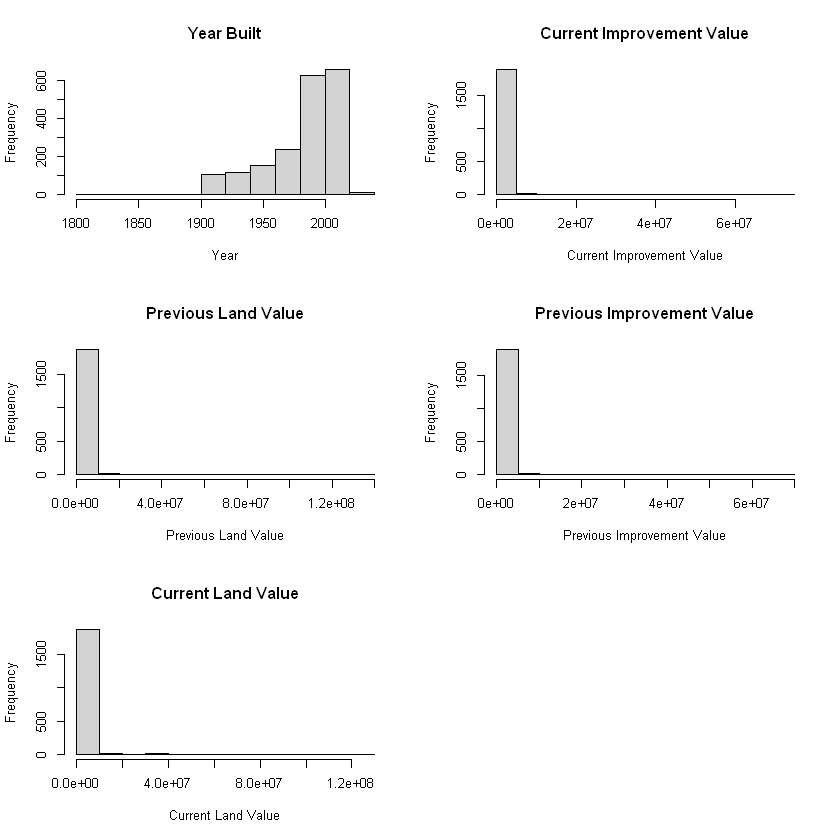

In [40]:
# Distribution Check
par(mfrow = c(3,2))
hist(property_cleaned$YEAR_BUILT,
     main = "Year Built",
     xlab = "Year")
hist(x = (property_cleaned$CURRENT_IMPROVEMENT_VALUE), main = "Current Improvement Value", xlab = "Current Improvement Value")
hist(x = (property_cleaned$PREVIOUS_LAND_VALUE), main = "Previous Land Value", xlab = "Previous Land Value")
hist(x = (property_cleaned$PREVIOUS_IMPROVEMENT_VALUE), main = "Previous Improvement Value", xlab = "Previous Improvement Value")
hist(x = (property_cleaned$CURRENT_LAND_VALUE), main = "Current Land Value", xlab = "Current Land Value")

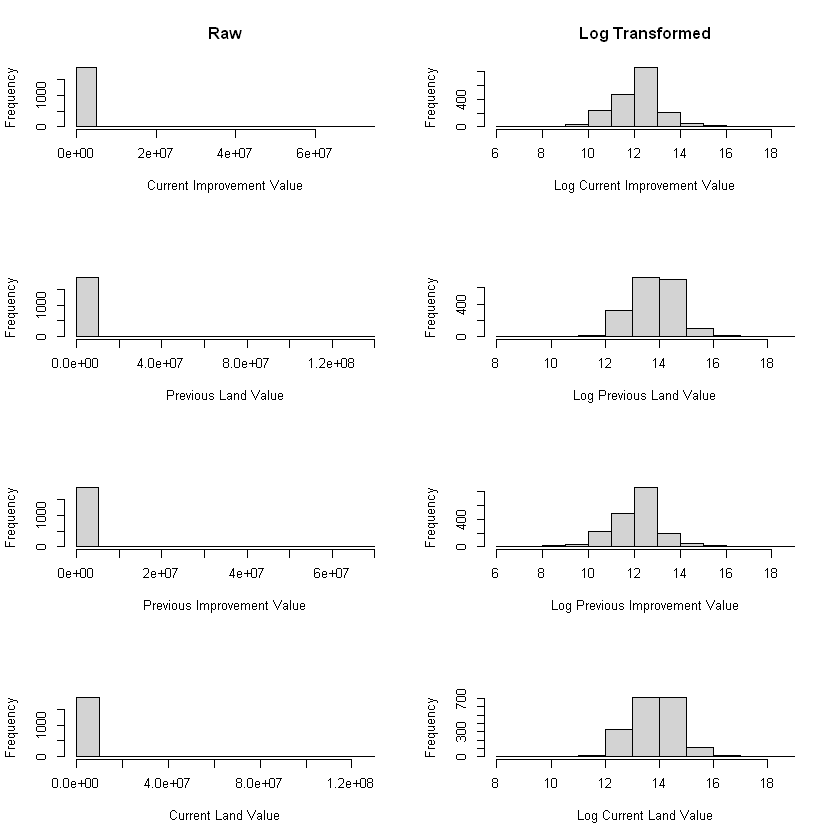

In [41]:
# Log-transformation Justification
par(mfrow = c(4,2))
hist(x = (property_cleaned$CURRENT_IMPROVEMENT_VALUE), main = "Raw", xlab = "Current Improvement Value")
hist(x = log(property_cleaned$CURRENT_IMPROVEMENT_VALUE), main = "Log Transformed", xlab = "Log Current Improvement Value")
hist(x = (property_cleaned$PREVIOUS_LAND_VALUE), main = "", xlab = "Previous Land Value")
hist(x = log(property_cleaned$PREVIOUS_LAND_VALUE), main = "", xlab = "Log Previous Land Value")
hist(x = (property_cleaned$PREVIOUS_IMPROVEMENT_VALUE), main = "", xlab = "Previous Improvement Value")
hist(x = log(property_cleaned$PREVIOUS_IMPROVEMENT_VALUE), main = "", xlab = "Log Previous Improvement Value")
hist(x = (property_cleaned$CURRENT_LAND_VALUE), main = "", xlab = "Current Land Value")
hist(x = log(property_cleaned$CURRENT_LAND_VALUE), main = "", xlab = "Log Current Land Value")

In [42]:
# Class Imbalance Check
counts1 <- table(property_cleaned$LEGAL_TYPE)
counts1

round(100 * prop.table(table(property_cleaned$LEGAL_TYPE)), 2)

counts2 <- table(property_cleaned$ZONING_CLASSIFICATION)
counts2

round(100 * prop.table(table(property_cleaned$ZONING_CLASSIFICATION)), 2)


  LAND STRATA 
   753   1142 


  LAND STRATA 
 39.74  60.26 


                 Commercial/Mixed       Industrial      Residential 
               8              856               55              944 
   Special/Other 
              32 


                 Commercial/Mixed       Industrial      Residential 
            0.42            45.17             2.90            49.82 
   Special/Other 
            1.69 

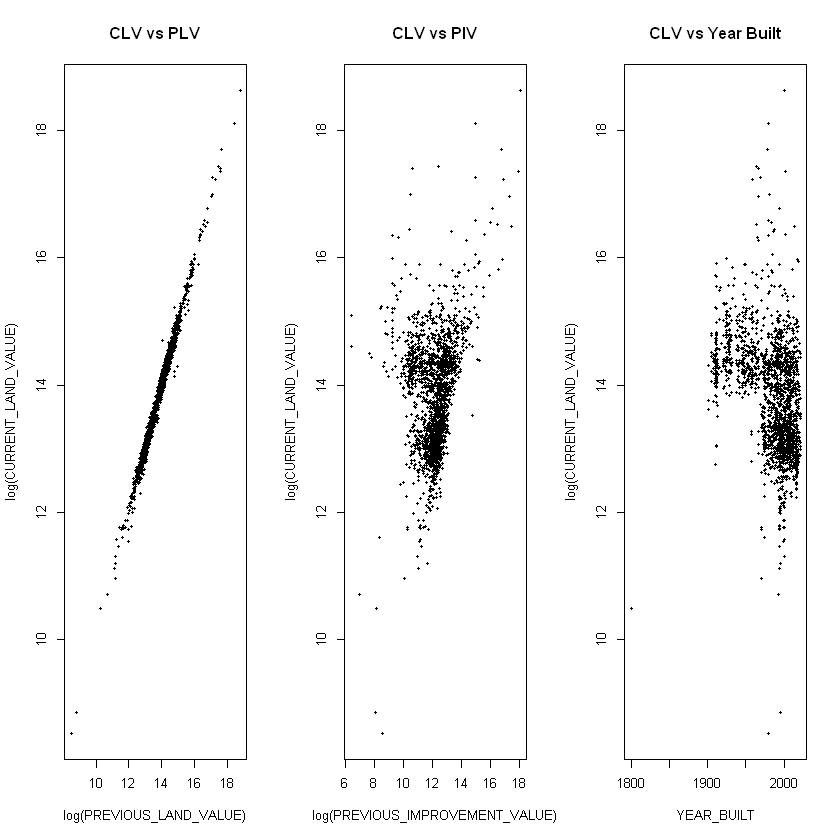

In [43]:
# Response vs Covariates
#png("scatterplots.png", width = 700, height = 400)

par(mfrow = c(1, 3))

plot(x = log(property_cleaned$PREVIOUS_LAND_VALUE),
     y = log(property_cleaned$CURRENT_LAND_VALUE),
     pch = 16, cex = 0.5,
     xlab = "log(PREVIOUS_LAND_VALUE)",
     ylab = "log(CURRENT_LAND_VALUE)",
     main = "CLV vs PLV")


plot(x = log(property_cleaned$PREVIOUS_IMPROVEMENT_VALUE),
     y = log(property_cleaned$CURRENT_LAND_VALUE),
     pch = 16, cex = 0.5,
     xlab = "log(PREVIOUS_IMPROVEMENT_VALUE)",
     ylab = "log(CURRENT_LAND_VALUE)",
     main = "CLV vs PIV")


plot(x = property_cleaned$YEAR_BUILT,
     y = log(property_cleaned$CURRENT_LAND_VALUE),
     pch = 16, cex = 0.5,
     xlab = "YEAR_BUILT",
     ylab = "log(CURRENT_LAND_VALUE)",
     main = "CLV vs Year Built")

#dev.off()

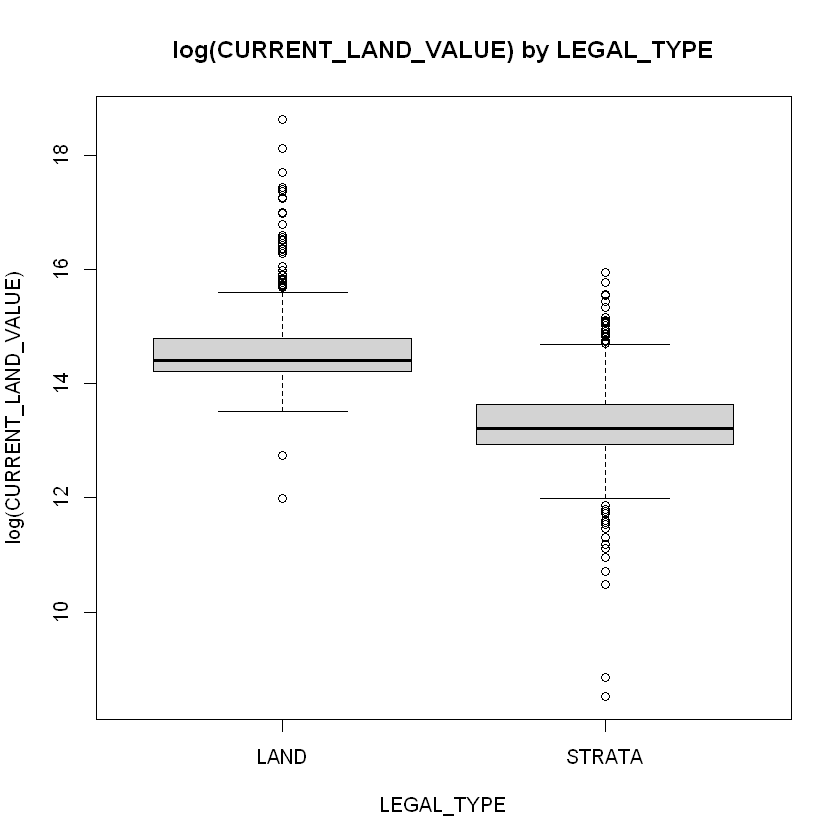

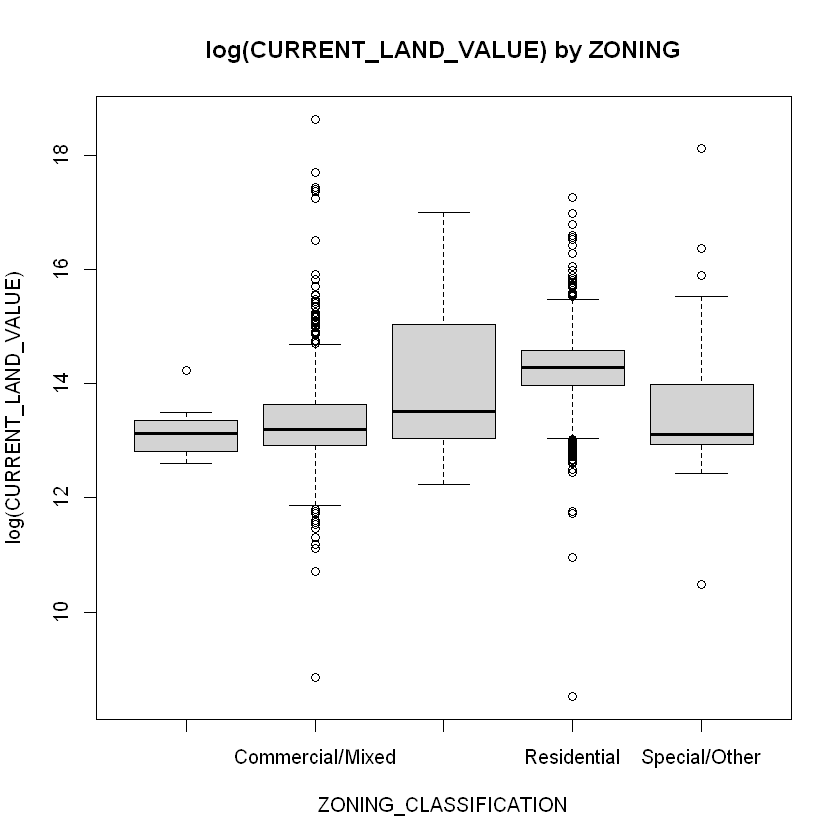

In [44]:
 par(mfrow = c(1, 1), mar = c(5,4,4,2))

boxplot(log(CURRENT_LAND_VALUE) ~ LEGAL_TYPE,
        data = property_cleaned,
        main = "log(CURRENT_LAND_VALUE) by LEGAL_TYPE",
        xlab = "LEGAL_TYPE",
        ylab = "log(CURRENT_LAND_VALUE)",
        col = "lightgray")

boxplot(log(CURRENT_LAND_VALUE) ~ ZONING_CLASSIFICATION,
        data = property_cleaned,
        main = "log(CURRENT_LAND_VALUE) by ZONING",
        xlab = "ZONING_CLASSIFICATION",
        ylab = "log(CURRENT_LAND_VALUE)",
        col = "lightgray")

par(mfrow = c(1, 1))

In [45]:
numeric_data <- data.frame(
  log_CURRENT_LAND_VALUE = log(property_cleaned$CURRENT_LAND_VALUE),
  log_PREVIOUS_LAND_VALUE = log(property_cleaned$PREVIOUS_LAND_VALUE),
  log_PREVIOUS_IMPROVEMENT_VALUE = log(property_cleaned$PREVIOUS_IMPROVEMENT_VALUE),
  YEAR_BUILT = property_cleaned$YEAR_BUILT
)

round(cor(numeric_data), 3)

,log_CURRENT_LAND_VALUE,log_PREVIOUS_LAND_VALUE,log_PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT
log_CURRENT_LAND_VALUE,1.000,0.994,0.232,-0.398
log_PREVIOUS_LAND_VALUE,0.994,1.000,0.239,-0.387
log_PREVIOUS_IMPROVEMENT_VALUE,0.232,0.239,1.000,0.394
YEAR_BUILT,-0.398,-0.387,0.394,1.000


--------------------------
#### Model Selection

In [46]:
# Define null and full model
fit_null <- lm(log(CURRENT_LAND_VALUE) ~ 1, data = property_cleaned)

fit_full <- lm(
                log(CURRENT_LAND_VALUE) ~ 
                    log(PREVIOUS_LAND_VALUE) +
                    log(PREVIOUS_IMPROVEMENT_VALUE) +
                    YEAR_BUILT +
                    LEGAL_TYPE +
                    ZONING_CLASSIFICATION,
                data = property_cleaned
                )

# Full stepwise (both directions)
fit_step <- step(fit_null, 
                 direction = "both", 
                 scope = formula(fit_full))

# Start from full model, remove predictors one by one
fit_backward <- step(fit_full, direction = "backward")

# Start from null, add predictors one by one
fit_forward <- step(fit_null, direction = "forward", scope = formula(fit_full))

# Summary of chosen model
cat("Stepwise Selection (both directions):")
summary(fit_step)
AIC(fit_step)

cat("Backward Selection:")
summary(fit_backward)
AIC(fit_backward)

cat("Forward Selection:")
summary(fit_forward)
AIC(fit_forward)

Start:  AIC=-464.08
log(CURRENT_LAND_VALUE) ~ 1

                                  Df Sum of Sq     RSS     AIC
+ log(PREVIOUS_LAND_VALUE)         1   1463.38   18.43 -8775.5
+ LEGAL_TYPE                       1    734.40  747.41 -1759.0
+ ZONING_CLASSIFICATION            4    357.66 1124.15  -979.5
+ YEAR_BUILT                       1    234.98 1246.83  -789.3
+ log(PREVIOUS_IMPROVEMENT_VALUE)  1     80.09 1401.72  -567.4
<none>                                         1481.81  -464.1

Step:  AIC=-8775.47
log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE)

                                  Df Sum of Sq     RSS     AIC
+ ZONING_CLASSIFICATION            4      0.74   17.69 -8845.6
+ LEGAL_TYPE                       1      0.49   17.94 -8825.1
+ YEAR_BUILT                       1      0.34   18.09 -8809.0
+ log(PREVIOUS_IMPROVEMENT_VALUE)  1      0.03   18.40 -8777.0
<none>                                           18.43 -8775.5
- log(PREVIOUS_LAND_VALUE)         1   1463.38 1481.81  -46


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    ZONING_CLASSIFICATION + LEGAL_TYPE + YEAR_BUILT + log(PREVIOUS_IMPROVEMENT_VALUE), 
    data = property_cleaned)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.59056 -0.05291  0.00719  0.05746  0.62402 

Coefficients:
                                        Estimate Std. Error t value Pr(>|t|)
(Intercept)                            0.8646452  0.2136076   4.048 5.38e-05
log(PREVIOUS_LAND_VALUE)               0.9675328  0.0039334 245.977  < 2e-16
ZONING_CLASSIFICATIONCommercial/Mixed  0.0916563  0.0342534   2.676 0.007519
ZONING_CLASSIFICATIONIndustrial        0.1161831  0.0365664   3.177 0.001511
ZONING_CLASSIFICATIONResidential       0.1220228  0.0345266   3.534 0.000419
ZONING_CLASSIFICATIONSpecial/Other     0.1101440  0.0382040   2.883 0.003983
LEGAL_TYPESTRATA                      -0.0220285  0.0081168  -2.714 0.006710
YEAR_BUILT                            -0.0002948  0.0001041  -2.831 0.0046

[1] -3479.926

Backward Selection:


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + LEGAL_TYPE + 
    ZONING_CLASSIFICATION, data = property_cleaned)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.59056 -0.05291  0.00719  0.05746  0.62402 

Coefficients:
                                        Estimate Std. Error t value Pr(>|t|)
(Intercept)                            0.8646452  0.2136076   4.048 5.38e-05
log(PREVIOUS_LAND_VALUE)               0.9675328  0.0039334 245.977  < 2e-16
log(PREVIOUS_IMPROVEMENT_VALUE)        0.0067677  0.0024877   2.720 0.006579
YEAR_BUILT                            -0.0002948  0.0001041  -2.831 0.004685
LEGAL_TYPESTRATA                      -0.0220285  0.0081168  -2.714 0.006710
ZONING_CLASSIFICATIONCommercial/Mixed  0.0916563  0.0342534   2.676 0.007519
ZONING_CLASSIFICATIONIndustrial        0.1161831  0.0365664   3.177 0.001511
ZONING_CLASSIFICATIONResidential       0.1220228  0.0345266   3.534 0.0004

[1] -3479.926

Forward Selection:


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    ZONING_CLASSIFICATION + LEGAL_TYPE + YEAR_BUILT + log(PREVIOUS_IMPROVEMENT_VALUE), 
    data = property_cleaned)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.59056 -0.05291  0.00719  0.05746  0.62402 

Coefficients:
                                        Estimate Std. Error t value Pr(>|t|)
(Intercept)                            0.8646452  0.2136076   4.048 5.38e-05
log(PREVIOUS_LAND_VALUE)               0.9675328  0.0039334 245.977  < 2e-16
ZONING_CLASSIFICATIONCommercial/Mixed  0.0916563  0.0342534   2.676 0.007519
ZONING_CLASSIFICATIONIndustrial        0.1161831  0.0365664   3.177 0.001511
ZONING_CLASSIFICATIONResidential       0.1220228  0.0345266   3.534 0.000419
ZONING_CLASSIFICATIONSpecial/Other     0.1101440  0.0382040   2.883 0.003983
LEGAL_TYPESTRATA                      -0.0220285  0.0081168  -2.714 0.006710
YEAR_BUILT                            -0.0002948  0.0001041  -2.831 0.0046

[1] -3479.926

--------------------------
#### Fitting Models

In [53]:
fit_add <- lm(
  log(CURRENT_LAND_VALUE) ~
    log(PREVIOUS_LAND_VALUE) +
    log(PREVIOUS_IMPROVEMENT_VALUE) +
    YEAR_BUILT +
    LEGAL_TYPE +
    ZONING_CLASSIFICATION,
  data = property_cleaned
)

fit_int_zone <- lm(
  log(CURRENT_LAND_VALUE) ~
    log(PREVIOUS_LAND_VALUE) * ZONING_CLASSIFICATION +
    log(PREVIOUS_IMPROVEMENT_VALUE) +
    YEAR_BUILT +
    LEGAL_TYPE,
  data = property_cleaned
)

fit_int_legal <- lm(
  log(CURRENT_LAND_VALUE) ~
    log(PREVIOUS_LAND_VALUE) * LEGAL_TYPE +
    log(PREVIOUS_IMPROVEMENT_VALUE) +
    YEAR_BUILT +
    ZONING_CLASSIFICATION,
  data = property_cleaned
)
anova_zone <- anova(fit_add, fit_int_zone)
anova_legal <- anova(fit_add, fit_int_legal)

data.frame(
  Model = c("Additive", "Zone interaction", "Legal interaction"),
  AIC = c(AIC(fit_add), AIC(fit_int_zone), AIC(fit_int_legal)),
  Adj_R2 = c(
    summary(fit_add)$adj.r.squared,
    summary(fit_int_zone)$adj.r.squared,
    summary(fit_int_legal)$adj.r.squared
  ),
  Residual_SE = c(
    summary(fit_add)$sigma,
    summary(fit_int_zone)$sigma,
    summary(fit_int_legal)$sigma
  ),
   F_value = c(
    NA,
    anova_zone$F[2],
    anova_legal$F[2]
  ),
  P_value = c(
    NA,
    anova_zone$`Pr(>F)`[2],
    anova_legal$`Pr(>F)`[2]
  )
)

Model,AIC,Adj_R2,Residual_SE,F_value,P_value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Additive,-3479.926,0.9881404,0.09632556,NA,NA
Zone interaction,-3481.368,0.9881743,0.09618795,2.350055,0.052233481
Legal interaction,-3486.942,0.9881904,0.09612219,8.989034,0.002751568


In [15]:
summary(fit)
tidy(vif(fit)) %>% rename(Predictor = names, VIF = x)


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, data = property_cleaned)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.61683 -0.05223  0.00452  0.06228  0.63983 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      1.354e+00  2.031e-01   6.667 3.42e-11 ***
log(PREVIOUS_LAND_VALUE)         9.814e-01  3.091e-03 317.487  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  3.983e-03  2.468e-03   1.614    0.107    
YEAR_BUILT                      -5.735e-04  9.709e-05  -5.907 4.13e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.09773 on 1891 degrees of freedom
Multiple R-squared:  0.9878,	Adjusted R-squared:  0.9878 
F-statistic: 5.108e+04 on 3 and 1891 DF,  p-value: < 2.2e-16


Warning message in tidy.numeric(vif(fit)):
"'tidy.numeric' is deprecated.
See help("Deprecated")"


Predictor,VIF
<chr>,<dbl>
log(PREVIOUS_LAND_VALUE),1.493432
log(PREVIOUS_IMPROVEMENT_VALUE),1.503636
YEAR_BUILT,1.667174


--------------------------
#### Analysis Plots

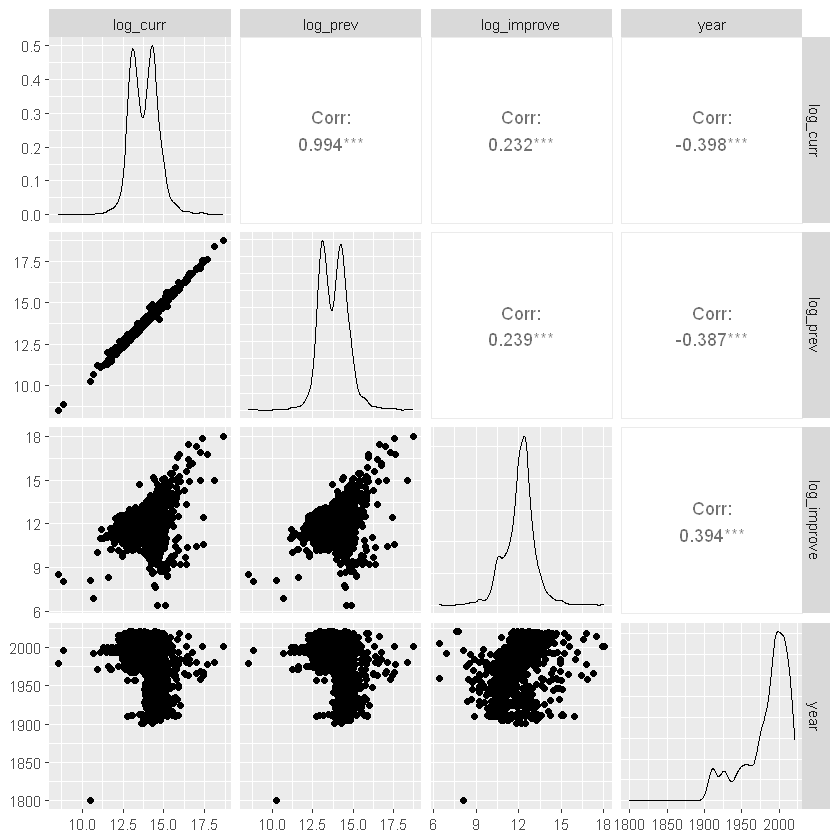

In [18]:
property_log <- property_cleaned |>
                mutate(log_curr = log(CURRENT_LAND_VALUE),
                log_prev = log(PREVIOUS_LAND_VALUE),
                log_improve = log(PREVIOUS_IMPROVEMENT_VALUE),
                year = as.numeric(YEAR_BUILT)) |>
                select(log_curr, log_prev, log_improve, year)
ggpairs(property_log)

`geom_smooth()` using formula = 'y ~ x'


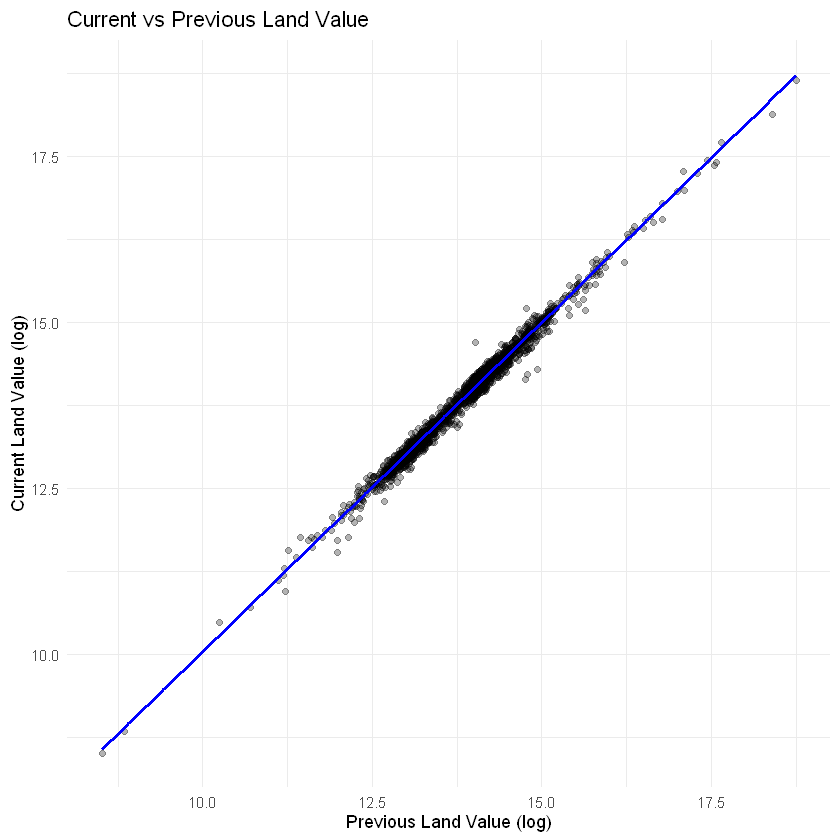

In [19]:
ggplot(property_cleaned, aes(x = log(PREVIOUS_LAND_VALUE), y = log(CURRENT_LAND_VALUE))) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(x = "Previous Land Value (log)", 
       y = "Current Land Value (log)",
       title = "Current vs Previous Land Value") +
  theme_minimal()

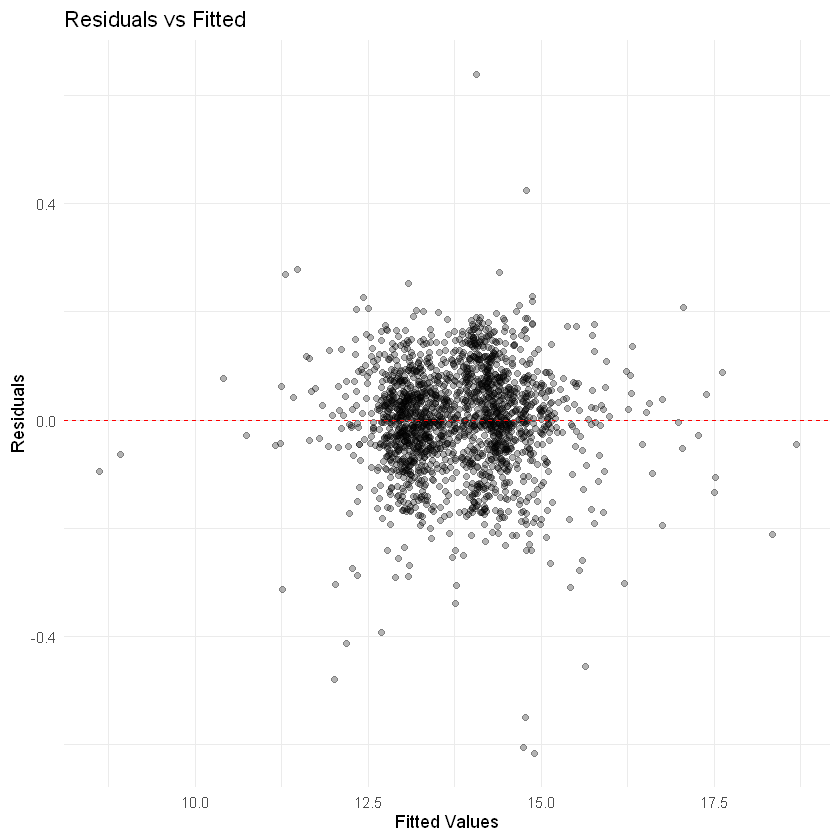

In [20]:
ggplot(data.frame(fitted = fit$fitted.values, residuals = fit$residuals),
       aes(x = fitted, y = residuals)) +
  geom_point(alpha = 0.3) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  labs(x = "Fitted Values", y = "Residuals",
       title = "Residuals vs Fitted") +
  theme_minimal()

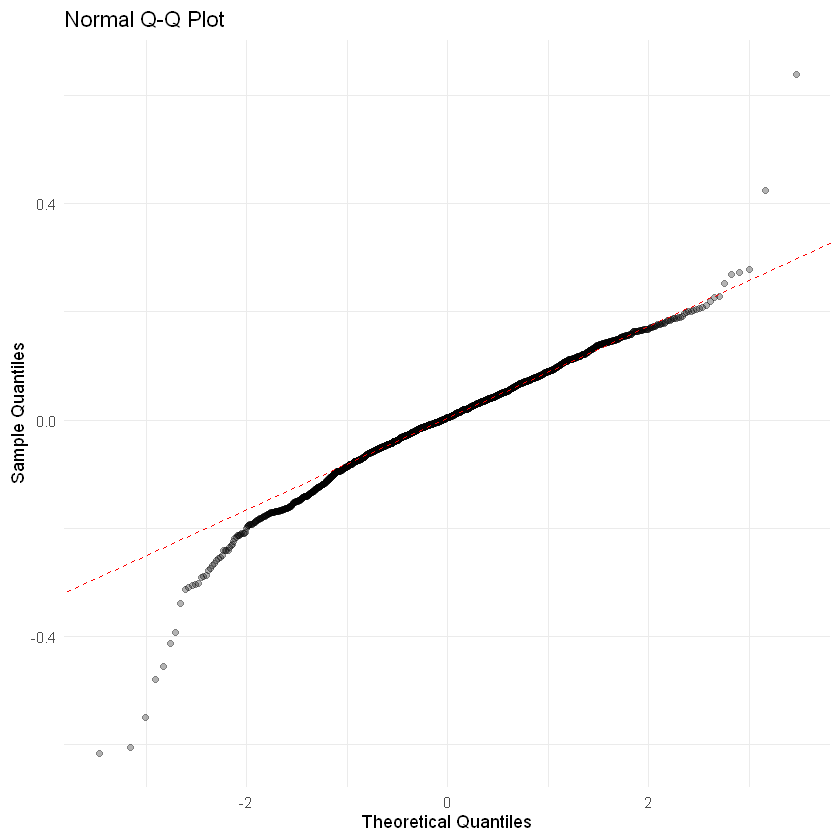

In [21]:
ggplot(data.frame(residuals = fit$residuals), aes(sample = residuals)) +
  stat_qq(alpha = 0.3) +
  stat_qq_line(color = "red", linetype = "dashed") +
  labs(x = "Theoretical Quantiles", y = "Sample Quantiles",
       title = "Normal Q-Q Plot") +
  theme_minimal()